Loading California Housing Dataset...

First Five Records
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Shape: (20640, 9)

Column Names
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -

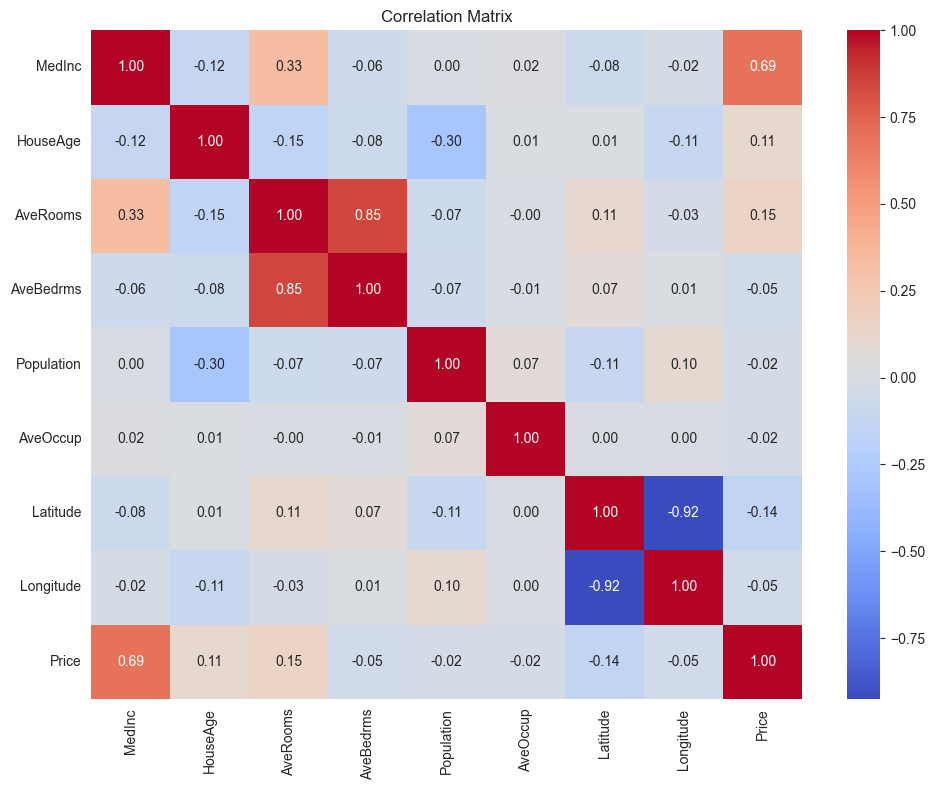

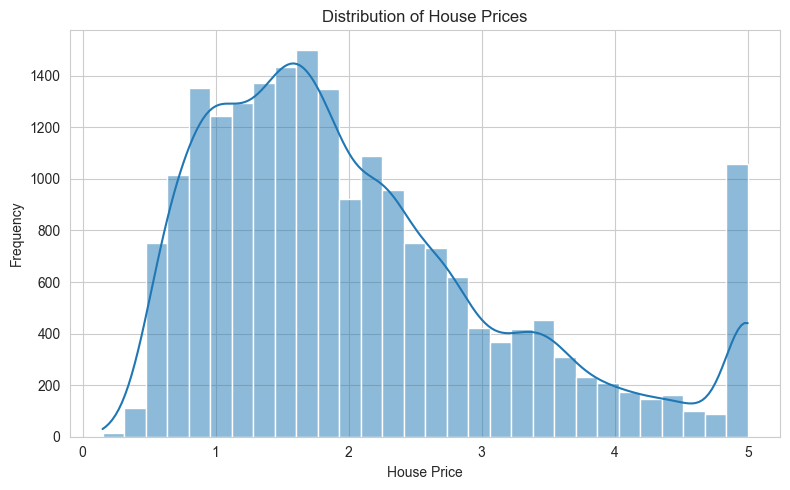

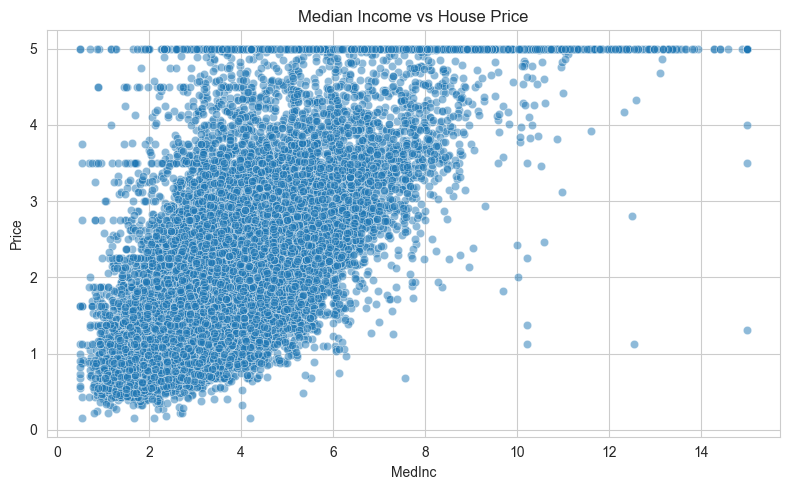


Training Samples : (16512, 8)
Testing Samples  : (4128, 8)

Training Linear Regression Model...
Model training completed successfully.

First 10 Predictions
[0.719 1.764 2.71  2.839 2.605 2.012 2.646 2.169 2.741 3.916]

Model Performance
------------------------------
Mean Absolute Error : 0.5332
Root Mean Squared Error : 0.7456
R² Score : 0.5758


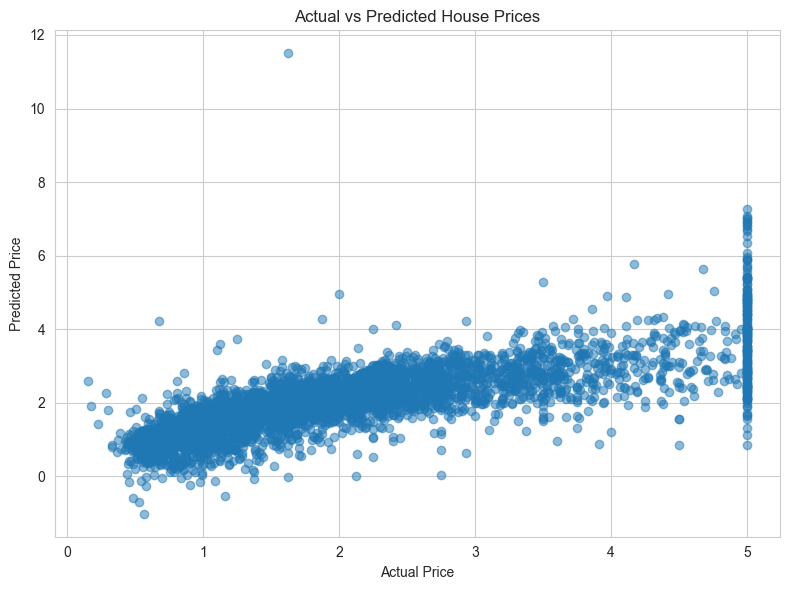


Model Coefficients
      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708

Model saved as linear_regression_model.pkl

Predicted House Price: 4.147


In [1]:
# ==========================================================
# House Price Prediction using Linear Regression
# California Housing Dataset
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def main():

    # ------------------------------------------------------
    # Load Dataset
    # ------------------------------------------------------
    print("=" * 50)
    print("Loading California Housing Dataset...")
    print("=" * 50)

    housing = fetch_california_housing()

    df = pd.DataFrame(housing.data, columns=housing.feature_names)
    df["Price"] = housing.target

    print("\nFirst Five Records")
    print(df.head())

    print("\nDataset Shape:", df.shape)

    print("\nColumn Names")
    print(df.columns.tolist())

    print("\nDataset Information")
    print(df.info())

    print("\nSummary Statistics")
    print(df.describe())

    print("\nMissing Values")
    print(df.isnull().sum())

    # ------------------------------------------------------
    # Exploratory Data Analysis
    # ------------------------------------------------------

    sns.set_style("whitegrid")

    # Correlation Heatmap
    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(),
                annot=True,
                cmap="coolwarm",
                fmt=".2f")
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

    # Price Distribution
    plt.figure(figsize=(8,5))
    sns.histplot(df["Price"], bins=30, kde=True)
    plt.title("Distribution of House Prices")
    plt.xlabel("House Price")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # Scatter Plot
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df,
                    x="MedInc",
                    y="Price",
                    alpha=0.5)
    plt.title("Median Income vs House Price")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Feature Selection
    # ------------------------------------------------------

    X = df.drop("Price", axis=1)
    y = df["Price"]

    # ------------------------------------------------------
    # Split Dataset
    # ------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    print("\nTraining Samples :", X_train.shape)
    print("Testing Samples  :", X_test.shape)

    # ------------------------------------------------------
    # Train Model
    # ------------------------------------------------------

    print("\nTraining Linear Regression Model...")

    model = LinearRegression()
    model.fit(X_train, y_train)

    print("Model training completed successfully.")

    # ------------------------------------------------------
    # Prediction
    # ------------------------------------------------------

    y_pred = model.predict(X_test)

    print("\nFirst 10 Predictions")
    print(np.round(y_pred[:10], 3))

    # ------------------------------------------------------
    # Model Evaluation
    # ------------------------------------------------------

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\nModel Performance")
    print("-" * 30)
    print(f"Mean Absolute Error : {mae:.4f}")
    print(f"Root Mean Squared Error : {rmse:.4f}")
    print(f"R² Score : {r2:.4f}")

    # ------------------------------------------------------
    # Actual vs Predicted Plot
    # ------------------------------------------------------

    plt.figure(figsize=(8,6))
    plt.scatter(y_test,
                y_pred,
                alpha=0.5)

    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title("Actual vs Predicted House Prices")

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Feature Importance
    # ------------------------------------------------------

    coefficients = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_
    })

    coefficients = coefficients.sort_values(
        by="Coefficient",
        ascending=False
    )

    print("\nModel Coefficients")
    print(coefficients)

    # ------------------------------------------------------
    # Save Model
    # ------------------------------------------------------

    joblib.dump(model, "linear_regression_model.pkl")
    print("\nModel saved as linear_regression_model.pkl")

    # ------------------------------------------------------
    # Predict Price for a New House
    # ------------------------------------------------------

    sample = pd.DataFrame(
        [[8.32,
          41,
          6.98,
          1.02,
          322,
          2.55,
          37.88,
          -122.23]],
        columns=X.columns
    )

    predicted_price = model.predict(sample)

    print(f"\nPredicted House Price: {predicted_price[0]:.3f}")


if __name__ == "__main__":
    main()